# Southend Pier -- Stage 2: UTide-Informed BiLSTM Decoder with Attention (PyTorch)

Stage 2 of the Thames tidal forecasting work. Stage 1 trained single-step LSTM/RNN/MLP models over a 96-step (16h) lookback of `Observed_ODN`. This stage replaces that with a **direct multi-horizon** forecaster:

- **Encoder**: same LSTM over 96 lagged `Observed_ODN` values as stage 1.
- **Decoder**: bidirectional LSTM stepping once per forecast horizon, fed the UTide harmonic reconstruction for that timestamp (known in advance).
- **Attention**: each decoder step attends over all 96 encoder hidden states.

No meteorological covariates yet -- that's stage 3.

**Data**: Southend Pier tide gauge, `3_Cleaned/10_SOUTHEND_chatter_and_stuck_patched.csv`, 10-minute readings, 2004-2024.

**Split**: train 2004-2017, validation 2018-2020, test 2021-2024.

## 1. Setup

In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


In [ ]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
    print(f"BF16 supported:  {torch.cuda.is_bf16_supported()}")
else:
    print("No GPU detected -- this notebook is sized for a Colab T4 (Runtime > Change runtime "
          "type > T4 GPU). It will still run on CPU, just much slower.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


PyTorch version: 2.11.0+cu128
CUDA available:  True
GPU:             NVIDIA A100-SXM4-80GB
BF16 supported:  True


In [ ]:
SEED = 42

# --- reused verbatim from stage 1 (initial_modelling.ipynb) ---
LOOKBACK = 96        # 16h of 10-minute steps, matches stage 1's encoder window
TRAIN_STRIDE = 3      # subsample training windows every 3rd step (30 min) to cut epoch time
BATCH_SIZE = 512      # halved vs. stage 1's 1024: attention + multi-horizon decoding costs more
                       # memory per sample, and this needs to fit comfortably on a T4, not an A100
EPOCHS = 60
PATIENCE = 10
LR = 1e-3
TRAIN_END = '2018-01-01'
VAL_END = '2021-01-01'

# --- stage-1 encoder hyperparameters, reused (not re-tuned here) ---
ENC_HIDDEN_SIZE = 64
ENC_NUM_LAYERS = 1

# --- new stage-2 decoder hyperparameters -- modest, no sweep in this notebook ---
DEC_HIDDEN_SIZE = 64
DEC_NUM_LAYERS = 1
ATTN_DIM = 64

# --- forecast horizons. 72h and 168h (1 week) extend stage 1's original five, since that's
# where a fixed-in-time UTide reconstruction should dominate a lookback-only model.
HORIZONS = {'10min': 1, '1h': 6, '6h': 36, '24h': 144, '48h': 288, '72h': 432, '168h': 1008}
HORIZON_NAMES = list(HORIZONS.keys())
HORIZON_STEPS = list(HORIZONS.values())
N_HORIZONS = len(HORIZON_STEPS)

# ~M2 semi-diurnal tidal period in 10-minute steps (12h 25.2min / 10min)
M2_STEPS = 74.5

SITE_LAT = 51.5145  # Southend Pier

STEP = pd.Timedelta('10min')


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
torch.backends.cudnn.benchmark = True

## 2. Load data (Google Drive)

In [4]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/tidal_analysis_and_prediction'
    DATA_PATH = os.path.join(BASE_DIR, '10_SOUTHEND_chatter_and_stuck_patched.csv')
    OUTPUT_DIR = os.path.join(BASE_DIR, 'stage2_outputs')
else:
    DATA_PATH = '../../3_Cleaned/10_SOUTHEND_chatter_and_stuck_patched.csv'
    OUTPUT_DIR = '../../outputs/stage2_outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
assert os.path.exists(DATA_PATH), f"Can't find data at {DATA_PATH} -- update DATA_PATH above."

import sys
if IN_COLAB:
    sys.path.insert(0, BASE_DIR)  # plot_config.py uploaded to the same Drive folder as the data
else:
    sys.path.insert(0, '../../utils')  # plot_config.py lives in the repo's utils/ folder
from plot_config import SERIES_COLOURS, save_fig, set_report_dir
set_report_dir(os.path.join(BASE_DIR, 'report_images') if IN_COLAB else '../../report_images')

LOAD_FROM_CHECKPOINT = True  # skip training and load saved weights from OUTPUT_DIR if present

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
usecols = ['DateTime', 'Observed_ODN', 'is_chatter_flagged', 'is_stuck_flagged', 'is_imputed']
df = pd.read_csv(DATA_PATH, usecols=usecols, parse_dates=['DateTime'])
df = df.sort_values('DateTime').reset_index(drop=True)
df['is_flagged'] = df['is_chatter_flagged'] | df['is_stuck_flagged'] | df['is_imputed']

gap_mask = df['DateTime'].diff() > STEP
print(f"{len(df):,} rows, {df.DateTime.min()} to {df.DateTime.max()}")
print(f"{gap_mask.sum()} gaps > 10min ({gap_mask.sum() + 1} contiguous segments)")
print(f"Flagged (chatter/stuck/imputed) points: {df['is_flagged'].sum():,} ({100 * df['is_flagged'].mean():.3f}%)")
df.head()


1,103,956 rows, 2004-01-01 00:00:00 to 2024-12-31 23:50:00
90 gaps > 10min (91 contiguous segments)
Flagged (chatter/stuck/imputed) points: 9,975 (0.904%)


,DateTime,is_imputed,Observed_ODN,is_chatter_flagged,is_stuck_flagged,is_flagged
0,2004-01-01 00:00:00,False,-1.819,False,False,False
1,2004-01-01 00:10:00,False,-1.855,False,False,False
2,2004-01-01 00:20:00,False,-1.874,False,False,False
3,2004-01-01 00:30:00,False,-1.895,False,False,False
4,2004-01-01 00:40:00,False,-1.904,False,False,False


## 3. UTide harmonic reconstruction

Fit on the training split only (2004-2017), flagged points excluded. Reconstructed across the full 2004-2024 span, used both as the decoder input feature and as the standalone `utide_baseline` comparator.

In [6]:
try:
    import utide
except ImportError:
    import sys
    !{sys.executable} -m pip install -q UTide
    import utide


In [7]:
train_mask_full = df['DateTime'] < TRAIN_END

fit_series = df.loc[train_mask_full, 'Observed_ODN'].copy()
fit_series[df.loc[train_mask_full, 'is_flagged']] = np.nan

coef = utide.solve(
    df.loc[train_mask_full, 'DateTime'], fit_series,
    lat=SITE_LAT, method='ols', conf_int='none',
)

recon = utide.reconstruct(pd.DatetimeIndex(df['DateTime']), coef, min_SNR=0, min_PE=0, verbose=False)
df['utide_recon'] = recon['h'].astype(np.float32)

print(f"UTide fit on {train_mask_full.sum():,} training rows "
      f"({(~np.isnan(fit_series)).sum():,} after excluding flagged points).")
print(f"Reconstructed {len(df):,} rows across the full 2004-2024 span.")
df[['DateTime', 'Observed_ODN', 'utide_recon']].head()


solve: matrix prep ... solution ... done.
UTide fit on 735,760 training rows (725,912 after excluding flagged points).
Reconstructed 1,103,956 rows across the full 2004-2024 span.


,DateTime,Observed_ODN,utide_recon
0,2004-01-01 00:00:00,-1.819,-1.201859
1,2004-01-01 00:10:00,-1.855,-1.226715
2,2004-01-01 00:20:00,-1.874,-1.242610
3,2004-01-01 00:30:00,-1.895,-1.249598
4,2004-01-01 00:40:00,-1.904,-1.247636


## 4. Chronological train / validation / test split

Same boundaries as stage 1.

In [8]:
train_df = df[df['DateTime'] < TRAIN_END].reset_index(drop=True)
val_df = df[(df['DateTime'] >= TRAIN_END) & (df['DateTime'] < VAL_END)].reset_index(drop=True)
test_df = df[df['DateTime'] >= VAL_END].reset_index(drop=True)

for split_name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f"{split_name:5s}: {len(split):>8,} rows  [{split.DateTime.min()} -> {split.DateTime.max()}]  "
          f"flagged={100 * split['is_flagged'].mean():.3f}%")


train:  735,760 rows  [2004-01-01 00:00:00 -> 2017-12-31 23:50:00]  flagged=1.338%
val  :  157,824 rows  [2018-01-01 00:00:00 -> 2020-12-31 23:50:00]  flagged=0.038%
test :  210,372 rows  [2021-01-01 00:00:00 -> 2024-12-31 23:50:00]  flagged=0.032%


## 5. Windowing

Each sample: a `LOOKBACK` window of past `Observed_ODN`, plus a target and a UTide decoder feature for each horizon in `HORIZON_STEPS`. Built within gap-free segments only. `Flag[i, j]` marks imputed/chatter/stuck targets.

In [ ]:
def build_windows_multi(sub_df, lookback, horizon_steps):
    sub_df = sub_df.reset_index(drop=True)
    is_gap = sub_df['DateTime'].diff() > STEP
    seg_id = is_gap.cumsum().to_numpy()

    values = sub_df['Observed_ODN'].to_numpy(dtype=np.float32)
    utide_vals = sub_df['utide_recon'].to_numpy(dtype=np.float32)
    flagged = sub_df['is_flagged'].to_numpy()
    times = sub_df['DateTime'].to_numpy()

    max_h = max(horizon_steps)
    horizon_arr = np.array(horizon_steps)

    X_list, Ydec_list, Y_list, Flag_list, Time_list = [], [], [], [], []
    for seg in np.unique(seg_id):
        idx = np.where(seg_id == seg)[0]
        n = len(idx)
        if n < lookback + max_h:
            continue

        seg_values = values[idx]
        seg_utide = utide_vals[idx]
        seg_flag = flagged[idx]
        seg_time = times[idx]

        n_windows = n - lookback - max_h + 1
        enc_windows = np.lib.stride_tricks.sliding_window_view(seg_values, lookback)[:n_windows]
        starts = np.arange(n_windows)
        # window `s` covers positions s .. s+lookback-1; horizon k's target sits at
        # s + (lookback - 1) + k, i.e. k steps after the last encoder value (k=1 -> next step)
        target_positions = starts[:, None] + (lookback - 1) + horizon_arr[None, :]

        X_list.append(enc_windows)
        Ydec_list.append(seg_utide[target_positions])
        Y_list.append(seg_values[target_positions])
        Flag_list.append(seg_flag[target_positions])
        Time_list.append(seg_time[target_positions])

    X = np.concatenate(X_list, axis=0)
    Ydec = np.concatenate(Ydec_list, axis=0)
    Y = np.concatenate(Y_list, axis=0)
    Flag = np.concatenate(Flag_list, axis=0)
    Time = np.concatenate(Time_list, axis=0)
    return X, Ydec, Y, Flag, Time


In [10]:
X_train, Ydec_train, Y_train, Flag_train, Time_train = build_windows_multi(train_df, LOOKBACK, HORIZON_STEPS)
X_val, Ydec_val, Y_val, Flag_val, Time_val = build_windows_multi(val_df, LOOKBACK, HORIZON_STEPS)
X_test, Ydec_test, Y_test, Flag_test, Time_test = build_windows_multi(test_df, LOOKBACK, HORIZON_STEPS)

X_train, Ydec_train, Y_train, Flag_train, Time_train = (
    X_train[::TRAIN_STRIDE], Ydec_train[::TRAIN_STRIDE], Y_train[::TRAIN_STRIDE],
    Flag_train[::TRAIN_STRIDE], Time_train[::TRAIN_STRIDE],
)

print(f"windows -> train: {X_train.shape} (stride {TRAIN_STRIDE}), val: {X_val.shape}, test: {X_test.shape}")
print(f"targets/horizon feature shape (N, {N_HORIZONS}): train {Y_train.shape}, val {Y_val.shape}, test {Y_test.shape}")


windows -> train: (223039, 96) (stride 3), val: (156721, 96), test: (199319, 96)
targets/horizon feature shape (N, 7): train (223039, 7), val (156721, 7), test (199319, 7)


## 6. Scaling

Standardised using the train split's `Observed_ODN` mean/std; `utide_recon` uses the same scaler.

In [11]:
train_mean = float(train_df['Observed_ODN'].mean())
train_std = float(train_df['Observed_ODN'].std())
print(f"train mean={train_mean:.4f} m, std={train_std:.4f} m")

def to_tensor(a, dtype=torch.float32):
    return torch.tensor(a, dtype=dtype, device=device)

def scale(a):
    return (a - train_mean) / train_std

X_train_t = to_tensor(scale(X_train))
Ydec_train_t = to_tensor(scale(Ydec_train))
Y_train_t = to_tensor(scale(Y_train))
Flag_train_t = to_tensor(Flag_train, dtype=torch.bool)

X_val_t = to_tensor(scale(X_val))
Ydec_val_t = to_tensor(scale(Ydec_val))
Y_val_t = to_tensor(scale(Y_val))
Flag_val_t = to_tensor(Flag_val, dtype=torch.bool)

X_test_t = to_tensor(scale(X_test))
Ydec_test_t = to_tensor(scale(Ydec_test))


train mean=0.1459 m, std=1.5730 m


## 7. Baselines

1. **Naive persistence** -- last observed value held flat.
2. **Tide-aware persistence** -- value one M2 cycle (~74.5 steps) before the forecast origin, wrapped for longer horizons.
3. **UTide standalone** -- the harmonic reconstruction alone.
4/5. **Stage-1 baselines (flat LSTM / flat MLP)** -- stage 1's architectures reproduced with a flat multi-horizon head, trained here since stage 1 never saved one.

In [12]:
def masked_rmse_mae(pred, true, flagged):
    # pred, true, flagged: (N, H) arrays -- returns per-horizon RMSE/MAE with flagged targets excluded.
    rmses, maes = [], []
    for j in range(pred.shape[1]):
        mask = ~flagged[:, j]
        err = pred[mask, j] - true[mask, j]
        rmses.append(float(np.sqrt(np.mean(err ** 2))))
        maes.append(float(np.mean(np.abs(err))))
    return np.array(rmses), np.array(maes)


def naive_persistence(X_raw, n_horizons):
    return np.repeat(X_raw[:, -1:], n_horizons, axis=1)


def tide_aware_persistence(X_raw, horizon_steps, m2_steps=M2_STEPS, lookback=LOOKBACK):
    # pred(t+k) = Observed_ODN(t + ref), where ref is k shifted back by whole M2 cycles
    # until it lands at or before the forecast origin (ref <= 0) -- so long horizons (e.g. 48h)
    # still only use already-observed history, with linear interpolation between the two nearest
    # lag steps since m2_steps isn't an integer.
    preds = np.zeros((X_raw.shape[0], len(horizon_steps)), dtype=np.float32)
    for j, k in enumerate(horizon_steps):
        ref = float(k) - m2_steps
        while ref >= -1e-9:
            ref -= m2_steps
        float_idx = lookback + ref  # fractional position within the lookback array
        idx0 = int(np.floor(float_idx))
        idx0 = max(0, min(idx0, lookback - 1))
        idx1 = min(idx0 + 1, lookback - 1)
        weight = float_idx - idx0
        preds[:, j] = (1 - weight) * X_raw[:, idx0] + weight * X_raw[:, idx1]
    return preds


In [13]:
results = []

naive_test = naive_persistence(X_test, N_HORIZONS)
rmse, mae = masked_rmse_mae(naive_test, Y_test, Flag_test)
for j, hname in enumerate(HORIZON_NAMES):
    results.append({'model': 'Naive persistence', 'horizon': hname, 'rmse_m': rmse[j], 'mae_m': mae[j]})

tide_pers_test = tide_aware_persistence(X_test, HORIZON_STEPS)
rmse, mae = masked_rmse_mae(tide_pers_test, Y_test, Flag_test)
for j, hname in enumerate(HORIZON_NAMES):
    results.append({'model': 'Tide-aware persistence', 'horizon': hname, 'rmse_m': rmse[j], 'mae_m': mae[j]})

# utide_baseline: the standalone comparator required alongside utide_recon. It is, by
# construction, the exact same reconstruction (same coef, same reconstruct() call) as the
# decoder feature above -- just sliced to the windowed test targets and used as a prediction
# in its own right, so the feature the model sees and the benchmark it's judged against can
# never diverge because of a constituent-selection difference.
utide_baseline = Ydec_test

rmse, mae = masked_rmse_mae(utide_baseline, Y_test, Flag_test)
for j, hname in enumerate(HORIZON_NAMES):
    results.append({'model': 'UTide standalone', 'horizon': hname, 'rmse_m': rmse[j], 'mae_m': mae[j]})

pd.DataFrame(results).pivot(index='model', columns='horizon', values='rmse_m')[HORIZON_NAMES].round(4)


horizon,10min,1h,6h,24h,48h,72h,168h
model,,,,,,,
Naive persistence,0.1329,0.7859,3.0826,0.7156,1.2962,1.8294,2.9235
Tide-aware persistence,0.4381,0.4379,0.4377,0.3802,0.5249,0.6975,1.1185
UTide standalone,0.2454,0.2454,0.2453,0.2445,0.2439,0.2438,0.2456


## 8. Models

### 8a. Shared encoder

Same LSTM as stage 1, but returns the full hidden-state sequence so the decoder's attention can look back over the whole history.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

    def forward(self, x):  # x: (B, T_hist, input_size)
        enc_outputs, (h_n, c_n) = self.lstm(x)
        return enc_outputs, (h_n, c_n)


### 8b. Attention

Additive dot-product attention: project decoder output and encoder states into `attn_dim`, score, softmax, weighted sum as context.

In [ ]:
class BatchedAttention(nn.Module):
    def __init__(self, dec_dim, enc_dim, attn_dim):
        super().__init__()
        self.dec_proj = nn.Linear(dec_dim, attn_dim)
        self.enc_proj = nn.Linear(enc_dim, attn_dim)

    def forward(self, dec_out, enc_outputs):
        q = self.dec_proj(dec_out)               # (B, H, attn_dim)
        k = self.enc_proj(enc_outputs)            # (B, T_hist, attn_dim)
        scores = torch.bmm(q, k.transpose(1, 2))  # (B, H, T_hist)
        weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(weights, enc_outputs)  # (B, H, enc_dim)
        return context, weights


### 8c. Decoder

Bidirectional LSTM, one step per horizon, fed `UTide(t+k)` at step `k`. Initial hidden/cell state projected from the encoder's final layer. Attention pulls context from the encoder at each step; prediction is a linear readout of `[decoder_output; attention_context]`.

In [ ]:
class TidalDecoder(nn.Module):
    def __init__(self, feat_size, hidden_size, enc_hidden_size, num_layers=1, attn_dim=None):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        attn_dim = attn_dim or hidden_size

        self.lstm = nn.LSTM(feat_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        self.init_h = nn.Linear(enc_hidden_size, num_layers * 2 * hidden_size)
        self.init_c = nn.Linear(enc_hidden_size, num_layers * 2 * hidden_size)
        self.attn = BatchedAttention(2 * hidden_size, enc_hidden_size, attn_dim)
        self.out = nn.Linear(2 * hidden_size + enc_hidden_size, 1)

    def forward(self, utide_future, enc_outputs, enc_final):
        h_n, c_n = enc_final                       # each (enc_num_layers, B, enc_hidden_size)
        h_last, c_last = h_n[-1], c_n[-1]           # final encoder layer only: (B, enc_hidden_size)
        B = h_last.size(0)

        h0 = self.init_h(h_last).view(B, self.num_layers * 2, self.hidden_size).permute(1, 0, 2).contiguous()
        c0 = self.init_c(c_last).view(B, self.num_layers * 2, self.hidden_size).permute(1, 0, 2).contiguous()

        dec_out, _ = self.lstm(utide_future, (h0, c0))       # (B, H, 2*hidden_size)
        context, weights = self.attn(dec_out, enc_outputs)   # (B, H, enc_hidden_size)
        combined = torch.cat([dec_out, context], dim=-1)
        return self.out(combined).squeeze(-1), weights        # (B, H)


### 8d. Full model and the stage-1 comparators

In [ ]:
class TidalSeq2Seq(nn.Module):
    # Stage 2: LSTM encoder + attention + BiLSTM decoder fed known-future UTide values.

    def __init__(self, enc_hidden_size, enc_num_layers, dec_hidden_size, dec_num_layers, attn_dim):
        super().__init__()
        self.encoder = Encoder(1, enc_hidden_size, enc_num_layers)
        self.decoder = TidalDecoder(1, dec_hidden_size, enc_hidden_size, dec_num_layers, attn_dim)

    def forward(self, x_hist, utide_future):
        enc_outputs, enc_final = self.encoder(x_hist.unsqueeze(-1))
        preds, weights = self.decoder(utide_future.unsqueeze(-1), enc_outputs, enc_final)
        return preds, weights


class FlatMultiHorizonLSTM(nn.Module):
    # Stage-1 reproduction: same LSTM encoder, but a flat linear head predicting all horizons
    # at once from the final hidden state -- no decoder, no UTide input, no attention. Stage 1's
    # own notebook only ever trained single-step models (evaluated via recursive rollout), so this
    # is trained here, with stage 1's exact encoder hyperparameters, as the fair direct-multi-horizon
    # baseline the new architecture needs to beat.

    def __init__(self, hidden_size, num_layers, n_horizons):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, n_horizons)

    def forward(self, x_hist):
        out, _ = self.lstm(x_hist.unsqueeze(-1))
        return self.head(out[:, -1, :])


class FlatMultiHorizonMLP(nn.Module):
    # Stage-1 reproduction of stage 1's MLP(lookback, hidden=(128, 64)): same body, but the
    # final layer predicts all horizons at once instead of a single next-step value.

    def __init__(self, lookback, n_horizons, hidden=(128, 64)):
        super().__init__()
        dims = [lookback, *hidden]
        layers = []
        for i in range(len(dims) - 1):
            layers += [nn.Linear(dims[i], dims[i + 1]), nn.ReLU()]
        layers.append(nn.Linear(dims[-1], n_horizons))
        self.net = nn.Sequential(*layers)

    def forward(self, x_hist):
        return self.net(x_hist)


## 9. Training

Masked MSE over all (sample, horizon) pairs, flagged targets excluded. All three models share one training loop.

In [ ]:
def batch_iter(tensors, batch_size, shuffle):
    n = tensors['X'].shape[0]
    idx = torch.randperm(n, device=tensors['X'].device) if shuffle else torch.arange(n, device=tensors['X'].device)
    for start in range(0, n, batch_size):
        b = idx[start:start + batch_size]
        yield {k: v[b] for k, v in tensors.items()}


def masked_mse(pred, true, flag_b):
    per_sample = (pred - true) ** 2
    return per_sample[~flag_b].mean()


def train_model(model, predict_fn, train_tensors, val_tensors, epochs, batch_size, lr, patience, label):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    use_amp = device.type == 'cuda'

    best_val = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        running_loss, n_seen = 0.0, 0
        for batch in batch_iter(train_tensors, batch_size, shuffle=True):
            opt.zero_grad()
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
                pred = predict_fn(model, batch)
                loss = masked_mse(pred, batch['Y'], batch['Flag'])
            loss.backward()
            opt.step()
            n_valid = int((~batch['Flag']).sum())
            running_loss += loss.item() * n_valid
            n_seen += n_valid
        train_loss = running_loss / n_seen

        model.eval()
        val_loss_sum, n_val = 0.0, 0
        with torch.no_grad():
            for batch in batch_iter(val_tensors, batch_size, shuffle=False):
                with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=use_amp):
                    pred = predict_fn(model, batch)
                    loss = masked_mse(pred, batch['Y'], batch['Flag'])
                n_valid = int((~batch['Flag']).sum())
                val_loss_sum += loss.item() * n_valid
                n_val += n_valid
        val_loss = val_loss_sum / n_val

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        sched.step(val_loss)

        improved = val_loss < best_val - 1e-6
        if improved:
            best_val = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"[{label}] epoch {epoch + 1:03d}  train_loss={train_loss:.5f}  val_loss={val_loss:.5f}"
              f"  lr={opt.param_groups[0]['lr']:.1e}{'  *' if improved else ''}")

        if epochs_no_improve >= patience:
            print(f"[{label}] early stopping at epoch {epoch + 1} (best val_loss={best_val:.5f})")
            break

    model.load_state_dict(best_state)
    return model, history


@torch.no_grad()
def compute_metrics(model, predict_fn, tensors, y_raw, flagged, batch_size=4096):
    model.eval()
    preds = []
    n = tensors['X'].shape[0]
    for start in range(0, n, batch_size):
        batch = {k: v[start:start + batch_size] for k, v in tensors.items() if k not in ('Y', 'Flag')}
        preds.append(predict_fn(model, batch))
    preds_m = torch.cat(preds).cpu().numpy() * train_std + train_mean
    rmse, mae = masked_rmse_mae(preds_m, y_raw, flagged)
    return rmse, mae, preds_m


def load_or_train(model, checkpoint_path, train_fn, label):
    # Skip training and load a saved state dict if LOAD_FROM_CHECKPOINT is set and one exists --
    # architecture hyperparameters above are fixed constants, not swept anywhere in this notebook
    # (s.9a/9b's search only tunes lr/weight_decay/batch_size), so re-instantiating the same class
    # is enough to make a saved state dict load cleanly.
    if LOAD_FROM_CHECKPOINT and os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        model.eval()
        print(f"[{label}] loaded weights from {checkpoint_path}")
        return model, None
    return train_fn(model)

In [ ]:
train_tensors_flat = {'X': X_train_t, 'Y': Y_train_t, 'Flag': Flag_train_t}
val_tensors_flat = {'X': X_val_t, 'Y': Y_val_t, 'Flag': Flag_val_t}
test_tensors_flat = {'X': X_test_t}

train_tensors_seq2seq = {'X': X_train_t, 'Ydec': Ydec_train_t, 'Y': Y_train_t, 'Flag': Flag_train_t}
val_tensors_seq2seq = {'X': X_val_t, 'Ydec': Ydec_val_t, 'Y': Y_val_t, 'Flag': Flag_val_t}
test_tensors_seq2seq = {'X': X_test_t, 'Ydec': Ydec_test_t}

predict_flat = lambda model, batch: model(batch['X'])
predict_seq2seq = lambda model, batch: model(batch['X'], batch['Ydec'])[0]


### 9a. Stage-1 baseline (reproduced): flat multi-horizon LSTM

In [20]:
checkpoint_path_s1_lstm = os.path.join(OUTPUT_DIR, 'stage1_flat_lstm_multihorizon.pt')


def _train_s1_lstm(m):
    return train_model(
        m, predict_flat, train_tensors_flat, val_tensors_flat,
        epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE, label='stage1-lstm',
    )


set_seed()
stage1_lstm_model = FlatMultiHorizonLSTM(ENC_HIDDEN_SIZE, ENC_NUM_LAYERS, N_HORIZONS).to(device)
stage1_lstm_model, stage1_lstm_history = load_or_train(
    stage1_lstm_model, checkpoint_path_s1_lstm, _train_s1_lstm, label='stage1-lstm')

[stage1-lstm] loaded weights from /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage1_flat_lstm_multihorizon.pt


### 9b. Stage-1 baseline (reproduced): flat multi-horizon MLP

In [21]:
checkpoint_path_s1_mlp = os.path.join(OUTPUT_DIR, 'stage1_flat_mlp_multihorizon.pt')


def _train_s1_mlp(m):
    return train_model(
        m, predict_flat, train_tensors_flat, val_tensors_flat,
        epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE, label='stage1-mlp',
    )


set_seed()
stage1_mlp_model = FlatMultiHorizonMLP(LOOKBACK, N_HORIZONS).to(device)
stage1_mlp_model, stage1_mlp_history = load_or_train(
    stage1_mlp_model, checkpoint_path_s1_mlp, _train_s1_mlp, label='stage1-mlp')

[stage1-mlp] loaded weights from /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage1_flat_mlp_multihorizon.pt


### 9c. Stage-2 model: encoder + attention + UTide-informed BiLSTM decoder

In [22]:
checkpoint_path_s2 = os.path.join(OUTPUT_DIR, 'stage2_tidal_seq2seq.pt')


def _train_s2(m):
    return train_model(
        m, predict_seq2seq, train_tensors_seq2seq, val_tensors_seq2seq,
        epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE, label='stage2-attn',
    )


set_seed()
stage2_model = TidalSeq2Seq(ENC_HIDDEN_SIZE, ENC_NUM_LAYERS, DEC_HIDDEN_SIZE, DEC_NUM_LAYERS, ATTN_DIM).to(device)
stage2_model, stage2_history = load_or_train(
    stage2_model, checkpoint_path_s2, _train_s2, label='stage2-attn')

[stage2-attn] loaded weights from /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_tidal_seq2seq.pt


In [23]:
loss_histories = [
    ('Stage 1 (flat LSTM)', stage1_lstm_history),
    ('Stage 1 (flat MLP)', stage1_mlp_history),
    ('Stage 2 (attn decoder)', stage2_history),
]
available_loss_histories = [(n, h) for n, h in loss_histories if h is not None]

if not available_loss_histories:
    print("All models loaded from checkpoint -- no training history to plot.")
else:
    # combined log-loss plot -- every available model's train/val curves on one axis, so
    # convergence speed and final loss level can be compared directly.
    fig = plt.figure(figsize=(8, 5))
    for name, history in available_loss_histories:
        epochs_arr = np.arange(1, len(history['train_loss']) + 1)
        color = SERIES_COLOURS.get(name)
        plt.plot(epochs_arr, history['train_loss'], label=f'{name} -- train', color=color, linestyle='-')
        plt.plot(epochs_arr, history['val_loss'], label=f'{name} -- val', color=color, linestyle='--')
    plt.yscale('log')
    plt.xlabel('epoch')
    plt.ylabel('MSE loss (scaled, log scale)')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3, which='both')
    plt.tight_layout()
    save_fig(fig, 'stage2_loss_curves_combined')
    plt.show()

All models loaded from checkpoint -- no training history to plot.


In [24]:
if not available_loss_histories:
    print("All models loaded from checkpoint -- no training history to plot.")
else:
    n = len(available_loss_histories)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4), squeeze=False)
    axes = axes[0]
    for ax, (name, history) in zip(axes, available_loss_histories):
        epochs_arr = np.arange(1, len(history['train_loss']) + 1)
        ax.plot(epochs_arr, history['train_loss'], label='train')
        ax.plot(epochs_arr, history['val_loss'], label='val')
        ax.set_yscale('log')
        ax.set_xlabel('epoch')
        ax.set_title(name, fontsize=11)
        ax.legend()
        ax.grid(alpha=0.3, which='both')
    axes[0].set_ylabel('MSE loss (scaled, log scale)')
    plt.tight_layout()
    save_fig(fig, 'stage2_loss_curves', width_in=6.3, height_in=6.3 * (4 / (6 * n)))
    plt.show()

All models loaded from checkpoint -- no training history to plot.


## 10. Evaluation (test set, touched once)

RMSE/MAE per horizon for all six comparators.

In [25]:
rmse_s1_lstm, mae_s1_lstm, test_preds_s1_lstm = compute_metrics(
    stage1_lstm_model, predict_flat, test_tensors_flat, Y_test, Flag_test)
rmse_s1_mlp, mae_s1_mlp, test_preds_s1_mlp = compute_metrics(
    stage1_mlp_model, predict_flat, test_tensors_flat, Y_test, Flag_test)
rmse_s2, mae_s2, test_preds_s2 = compute_metrics(
    stage2_model, predict_seq2seq, test_tensors_seq2seq, Y_test, Flag_test)

for j, hname in enumerate(HORIZON_NAMES):
    results.append({'model': 'Stage-1 baseline (flat LSTM)', 'horizon': hname, 'rmse_m': rmse_s1_lstm[j], 'mae_m': mae_s1_lstm[j]})
    results.append({'model': 'Stage-1 baseline (flat MLP)', 'horizon': hname, 'rmse_m': rmse_s1_mlp[j], 'mae_m': mae_s1_mlp[j]})
    results.append({'model': 'Stage-2 (attn decoder)', 'horizon': hname, 'rmse_m': rmse_s2[j], 'mae_m': mae_s2[j]})

metrics_df = pd.DataFrame(results)
metrics_path = os.path.join(OUTPUT_DIR, 'stage2_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f"saved {metrics_path}")

metrics_df.pivot(index='model', columns='horizon', values='rmse_m')[HORIZON_NAMES].round(4)


saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_metrics.csv


horizon,10min,1h,6h,24h,48h,72h,168h
model,,,,,,,
Naive persistence,0.1329,0.7859,3.0826,0.7156,1.2962,1.8294,2.9235
Stage-1 baseline (flat LSTM),0.0239,0.0708,0.2567,0.2996,0.3858,0.5009,0.7840
Stage-1 baseline (flat MLP),0.0296,0.0667,0.2488,0.2923,0.3865,0.5089,0.7992
Stage-2 (attn decoder),0.0173,0.0519,0.1882,0.2230,0.2260,0.2284,0.2347
Tide-aware persistence,0.4381,0.4379,0.4377,0.3802,0.5249,0.6975,1.1185
UTide standalone,0.2454,0.2454,0.2453,0.2445,0.2439,0.2438,0.2456


In [26]:
metrics_df.pivot(index='model', columns='horizon', values='mae_m')[HORIZON_NAMES].round(4)


horizon,10min,1h,6h,24h,48h,72h,168h
model,,,,,,,
Naive persistence,0.1181,0.6994,2.7221,0.6068,1.1302,1.6096,2.6080
Stage-1 baseline (flat LSTM),0.0172,0.0510,0.1883,0.2203,0.2971,0.3903,0.6018
Stage-1 baseline (flat MLP),0.0216,0.0478,0.1820,0.2144,0.2991,0.3986,0.6205
Stage-2 (attn decoder),0.0118,0.0365,0.1330,0.1545,0.1594,0.1614,0.1676
Tide-aware persistence,0.3268,0.3267,0.3266,0.2782,0.4064,0.5545,0.9179
UTide standalone,0.1771,0.1771,0.1770,0.1766,0.1764,0.1763,0.1772


saved /content/drive/MyDrive/tidal_analysis_and_prediction/report_images/stage2_rmse_vs_horizon.pdf


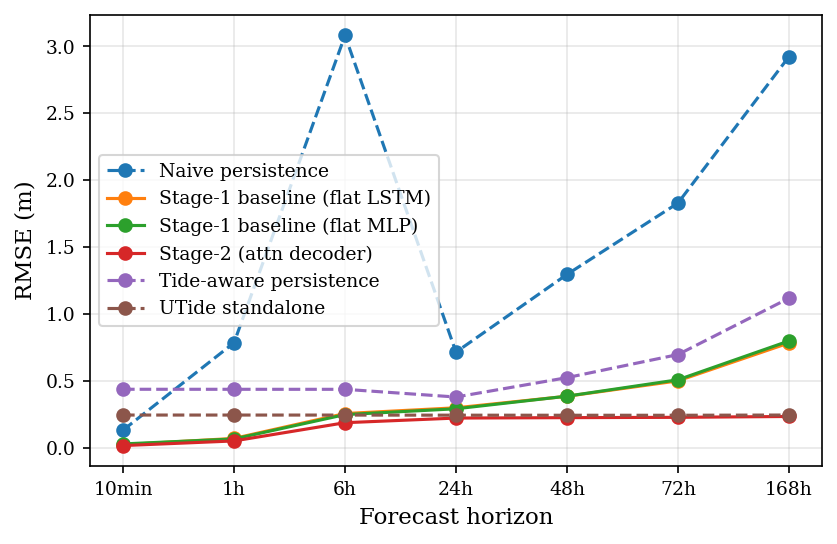

In [27]:
fig = plt.figure(figsize=(8, 5))
rmse_pivot = metrics_df.pivot(index='model', columns='horizon', values='rmse_m')[HORIZON_NAMES]
for name in rmse_pivot.index:
    style = '--' if 'UTide' in name or 'persistence' in name else '-'
    plt.plot(rmse_pivot.columns, rmse_pivot.loc[name], marker='o', linestyle=style, label=name,
              color=SERIES_COLOURS.get(name))
plt.xlabel('Forecast horizon')
plt.ylabel('RMSE (m)')
plt.legend()
plt.grid(alpha=0.3)
save_fig(fig, 'stage2_rmse_vs_horizon')
plt.show()

## 11. Save outputs to Google Drive

In [28]:
checkpoint_path = os.path.join(OUTPUT_DIR, 'stage2_tidal_seq2seq.pt')
torch.save({
    'model_state_dict': stage2_model.state_dict(),
    'config': {
        'enc_hidden_size': ENC_HIDDEN_SIZE,
        'enc_num_layers': ENC_NUM_LAYERS,
        'dec_hidden_size': DEC_HIDDEN_SIZE,
        'dec_num_layers': DEC_NUM_LAYERS,
        'attn_dim': ATTN_DIM,
        'lookback': LOOKBACK,
        'horizons': HORIZONS,
    },
    'scaler': {'mean': train_mean, 'std': train_std},
}, checkpoint_path)

stage1_lstm_checkpoint_path = os.path.join(OUTPUT_DIR, 'stage1_flat_lstm_multihorizon.pt')
torch.save({
    'model_state_dict': stage1_lstm_model.state_dict(),
    'config': {
        'hidden_size': ENC_HIDDEN_SIZE,
        'num_layers': ENC_NUM_LAYERS,
        'lookback': LOOKBACK,
        'horizons': HORIZONS,
    },
    'scaler': {'mean': train_mean, 'std': train_std},
}, stage1_lstm_checkpoint_path)

stage1_mlp_checkpoint_path = os.path.join(OUTPUT_DIR, 'stage1_flat_mlp_multihorizon.pt')
torch.save({
    'model_state_dict': stage1_mlp_model.state_dict(),
    'config': {
        'hidden': (128, 64),
        'lookback': LOOKBACK,
        'horizons': HORIZONS,
    },
    'scaler': {'mean': train_mean, 'std': train_std},
}, stage1_mlp_checkpoint_path)

print(f"saved {checkpoint_path}")
print(f"saved {stage1_lstm_checkpoint_path}")
print(f"saved {stage1_mlp_checkpoint_path}")
print(f"saved {metrics_path}")
print(f"\nAll stage-2 outputs are under: {OUTPUT_DIR}")

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_tidal_seq2seq.pt
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage1_flat_lstm_multihorizon.pt
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage1_flat_mlp_multihorizon.pt
saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_metrics.csv

All stage-2 outputs are under: /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs


## 12. Next steps

- Add meteorological covariates (pressure, discharge, rainfall, wind) -- stage 3.
- Sweep decoder hidden size, layers, attention dimension.
- Inspect attention weights per horizon.
- Check performance around storm surge periods.

## 13. Robustness checks

- **13.1 Tide-input ablation.** Retrain the same architecture with the decoder input zeroed out, to isolate the tidal signal's contribution.
- **13.2 Forecast accuracy later in the test window.** Slice test-set accuracy by calendar year and by specific weeks.
- **13.3 Sensitivity to training-data volume.** Retrain on the last 3, 7, and 10 years instead of all 14.

### 13.1 Isolating the tidal input's contribution

Retrains `TidalSeq2Seq` with the decoder always fed zeros instead of the UTide reconstruction. Any RMSE gap vs. `stage2_model` is attributable to the tidal input alone.

In [29]:
predict_seq2seq_notide = lambda model, batch: model(batch['X'], torch.zeros_like(batch['Ydec']))[0]

checkpoint_path_s2_notide = os.path.join(OUTPUT_DIR, 'stage2_tidal_seq2seq_notide_ablation.pt')


def _train_s2_notide(m):
    return train_model(
        m, predict_seq2seq_notide, train_tensors_seq2seq, val_tensors_seq2seq,
        epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE, label='stage2-no-tide-ablation',
    )


set_seed()
stage2_notide_model = TidalSeq2Seq(ENC_HIDDEN_SIZE, ENC_NUM_LAYERS, DEC_HIDDEN_SIZE, DEC_NUM_LAYERS, ATTN_DIM).to(device)
stage2_notide_model, stage2_notide_history = load_or_train(
    stage2_notide_model, checkpoint_path_s2_notide, _train_s2_notide, label='stage2-no-tide-ablation')
torch.save({'model_state_dict': stage2_notide_model.state_dict(),
            'scaler': {'mean': train_mean, 'std': train_std}}, checkpoint_path_s2_notide)
print(f"saved {checkpoint_path_s2_notide}")

rmse_notide, mae_notide, test_preds_notide = compute_metrics(
    stage2_notide_model, predict_seq2seq_notide, test_tensors_seq2seq, Y_test, Flag_test)

[stage2-no-tide-ablation] epoch 001  train_loss=0.21664  val_loss=0.09187  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 002  train_loss=0.08838  val_loss=0.08599  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 003  train_loss=0.08461  val_loss=0.08359  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 004  train_loss=0.08267  val_loss=0.08085  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 005  train_loss=0.08004  val_loss=0.07913  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 006  train_loss=0.07725  val_loss=0.07544  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 007  train_loss=0.07485  val_loss=0.07466  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 008  train_loss=0.07325  val_loss=0.07318  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 009  train_loss=0.07203  val_loss=0.07208  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 010  train_loss=0.07082  val_loss=0.07177  lr=1.0e-03  *
[stage2-no-tide-ablation] epoch 011  train_loss=0.07045  val_loss=0.06906  lr=1.0e-03  *
[stage2-no-tide-ablat

In [30]:
ablation_results = []
rmse_naive_a, mae_naive_a = masked_rmse_mae(naive_test, Y_test, Flag_test)
rmse_tp_a, mae_tp_a = masked_rmse_mae(tide_pers_test, Y_test, Flag_test)
rmse_utide_a, mae_utide_a = masked_rmse_mae(utide_baseline, Y_test, Flag_test)

for j, hname in enumerate(HORIZON_NAMES):
    ablation_results.append({'model': 'Naive persistence', 'horizon': hname, 'rmse_m': rmse_naive_a[j], 'mae_m': mae_naive_a[j]})
    ablation_results.append({'model': 'Tide-aware persistence', 'horizon': hname, 'rmse_m': rmse_tp_a[j], 'mae_m': mae_tp_a[j]})
    ablation_results.append({'model': 'UTide standalone', 'horizon': hname, 'rmse_m': rmse_utide_a[j], 'mae_m': mae_utide_a[j]})
    ablation_results.append({'model': 'Stage-2 (with tide)', 'horizon': hname, 'rmse_m': rmse_s2[j], 'mae_m': mae_s2[j]})
    ablation_results.append({'model': 'Stage-2 (no tide, ablation)', 'horizon': hname, 'rmse_m': rmse_notide[j], 'mae_m': mae_notide[j]})

ablation_df = pd.DataFrame(ablation_results)
ablation_metrics_path = os.path.join(OUTPUT_DIR, 'stage2_ablation_metrics.csv')
ablation_df.to_csv(ablation_metrics_path, index=False)
print(f"saved {ablation_metrics_path}")

ablation_pivot = ablation_df.pivot(index='model', columns='horizon', values='rmse_m')[HORIZON_NAMES]
ablation_pivot = ablation_pivot.loc[['Naive persistence', 'Tide-aware persistence', 'UTide standalone',
                                      'Stage-2 (no tide, ablation)', 'Stage-2 (with tide)']]
ablation_pivot.round(4)

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_ablation_metrics.csv


horizon,10min,1h,6h,24h,48h,72h,168h
model,,,,,,,
Naive persistence,0.1329,0.7859,3.0826,0.7156,1.2962,1.8294,2.9235
Tide-aware persistence,0.4381,0.4379,0.4377,0.3802,0.5249,0.6975,1.1185
UTide standalone,0.2454,0.2454,0.2453,0.2445,0.2439,0.2438,0.2456
"Stage-2 (no tide, ablation)",0.0217,0.0593,0.2433,0.2956,0.3827,0.4944,0.7766
Stage-2 (with tide),0.0173,0.0519,0.1882,0.2230,0.2260,0.2284,0.2347


saved /content/drive/MyDrive/tidal_analysis_and_prediction/report_images/stage2_ablation_rmse_vs_horizon.pdf


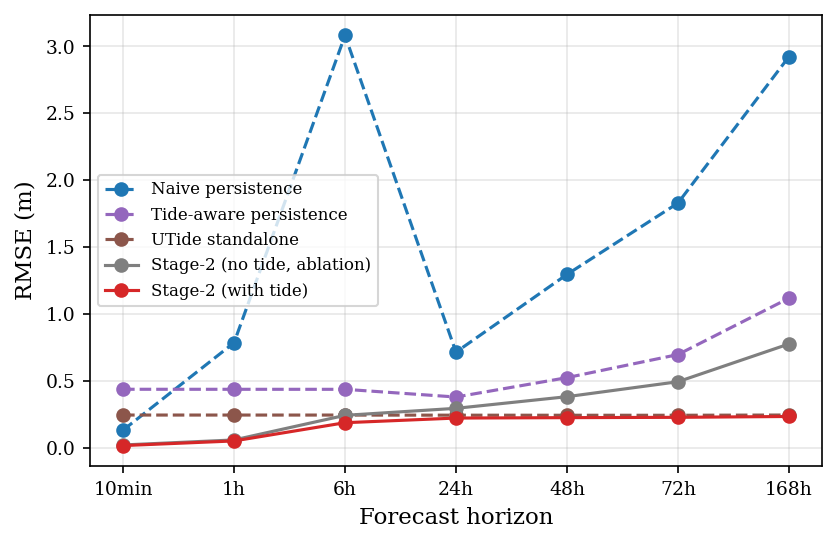

   10min: removing the tidal input increases RMSE by 20.6%
      1h: removing the tidal input increases RMSE by 12.5%
      6h: removing the tidal input increases RMSE by 22.6%
     24h: removing the tidal input increases RMSE by 24.6%
     48h: removing the tidal input increases RMSE by 41.0%
     72h: removing the tidal input increases RMSE by 53.8%
    168h: removing the tidal input increases RMSE by 69.8%


In [31]:
fig = plt.figure(figsize=(8, 5))
for name in ablation_pivot.index:
    style = '--' if name in ('Naive persistence', 'Tide-aware persistence', 'UTide standalone') else '-'
    plt.plot(HORIZON_NAMES, ablation_pivot.loc[name], marker='o', linestyle=style, label=name,
              color=SERIES_COLOURS.get(name))
plt.xlabel('Forecast horizon')
plt.ylabel('RMSE (m)')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
save_fig(fig, 'stage2_ablation_rmse_vs_horizon')
plt.show()

tide_contribution_pct = 100 * (rmse_notide - rmse_s2) / rmse_notide
for h, pct in zip(HORIZON_NAMES, tide_contribution_pct):
    print(f"  {h:>6s}: removing the tidal input increases RMSE by {pct:.1f}%")

### 13.2 Forecast accuracy later in the test window

Slices `stage2_model`'s existing test predictions by calendar year and by specific weeks, to check whether accuracy holds up further from the 2018 training cutoff.

In [32]:
year_rows = []
years_present = sorted(pd.DatetimeIndex(Time_test[:, 0]).year.unique())
for yr in years_present:
    for j, hname in enumerate(HORIZON_NAMES):
        t = pd.DatetimeIndex(Time_test[:, j])
        yr_mask = t.year == yr
        if yr_mask.sum() == 0:
            continue
        err = test_preds_s2[yr_mask, j] - Y_test[yr_mask, j]
        flg = Flag_test[yr_mask, j]
        err = err[~flg]
        year_rows.append({'year': yr, 'horizon': hname, 'rmse_m': float(np.sqrt(np.mean(err ** 2))), 'n': len(err)})

year_df = pd.DataFrame(year_rows)
year_metrics_path = os.path.join(OUTPUT_DIR, 'stage2_rmse_by_calendar_year.csv')
year_df.to_csv(year_metrics_path, index=False)
print(f"saved {year_metrics_path}")

year_pivot = year_df.pivot(index='year', columns='horizon', values='rmse_m')[HORIZON_NAMES]
year_pivot.round(4)

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_rmse_by_calendar_year.csv


horizon,10min,1h,6h,24h,48h,72h,168h
year,,,,,,,
2021,0.0168,0.0486,0.1772,0.2132,0.2169,0.2185,0.2235
2022,0.0194,0.0593,0.1995,0.2360,0.2359,0.2390,0.2430
2023,0.0157,0.0486,0.1842,0.2182,0.2216,0.2231,0.2263
2024,0.0169,0.0503,0.1917,0.2241,0.2292,0.2328,0.2454


saved /content/drive/MyDrive/tidal_analysis_and_prediction/report_images/stage2_rmse_by_calendar_year.pdf


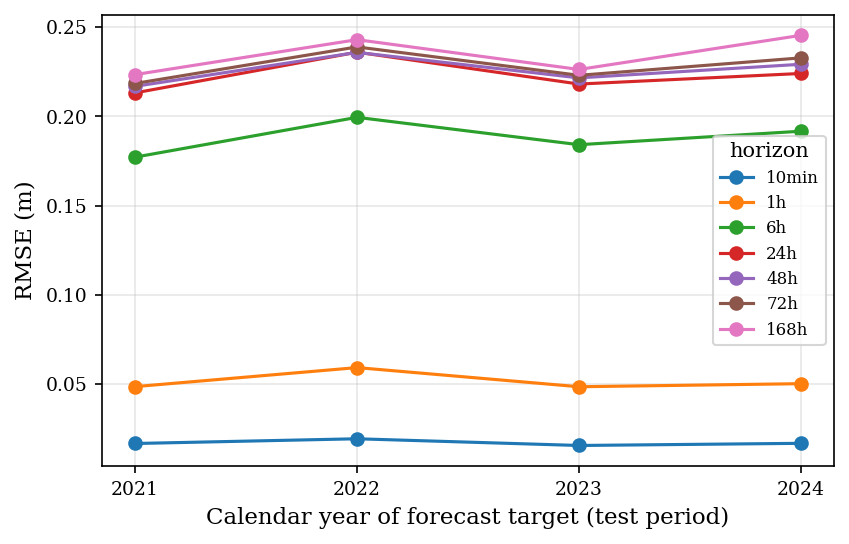

In [33]:
fig = plt.figure(figsize=(8, 5))
for hname in HORIZON_NAMES:
    plt.plot(year_pivot.index, year_pivot[hname], marker='o', label=hname)
plt.xlabel('Calendar year of forecast target (test period)')
plt.ylabel('RMSE (m)')
plt.legend(title='horizon', fontsize=8)
plt.grid(alpha=0.3)
plt.xticks(year_pivot.index)
save_fig(fig, 'stage2_rmse_by_calendar_year')
plt.show()

In [34]:
def week_metrics(week_start, label, preds=test_preds_s2):
    week_start = pd.Timestamp(week_start)
    week_end = week_start + pd.Timedelta(days=7)
    rows = []
    for j, hname in enumerate(HORIZON_NAMES):
        t = pd.DatetimeIndex(Time_test[:, j])
        mask = (t >= week_start) & (t < week_end)
        if mask.sum() == 0:
            continue
        err = preds[mask, j] - Y_test[mask, j]
        flg = Flag_test[mask, j]
        err = err[~flg]
        rows.append({'week': label, 'horizon': hname, 'rmse_m': float(np.sqrt(np.mean(err ** 2))), 'n': len(err)})
    return rows


week_starts = {
    '2021-W1 (start of test)': '2021-01-01',
    '2022-W1': '2022-01-01',
    '2024-W1 (3yr into test)': '2024-01-01',
}
week_rows = []
for label, start in week_starts.items():
    week_rows += week_metrics(start, label)

week_df = pd.DataFrame(week_rows)
week_metrics_path = os.path.join(OUTPUT_DIR, 'stage2_rmse_by_test_week.csv')
week_df.to_csv(week_metrics_path, index=False)
print(f"saved {week_metrics_path}")

week_pivot = week_df.pivot(index='week', columns='horizon', values='rmse_m')[HORIZON_NAMES]
week_pivot.round(4)

saved /content/drive/MyDrive/tidal_analysis_and_prediction/stage2_outputs/stage2_rmse_by_test_week.csv


horizon,10min,1h,6h,24h,48h,72h,168h
week,,,,,,,
2021-W1 (start of test),0.0127,0.0420,0.1064,0.0969,0.1064,0.0943,NaN
2022-W1,0.0361,0.1050,0.3180,0.3908,0.3984,0.4011,0.4048
2024-W1 (3yr into test),0.0169,0.0546,0.1604,0.1539,0.1530,0.1646,0.1804


### 13.3 Sensitivity to training-data volume

Train end fixed at 2018-01-01; only the training window start moves: 2015 (3yr), 2011 (7yr), 2008 (10yr), vs. the full 2004-2018 (14yr). UTide refit separately per window.

In [35]:
REDUCED_TRAIN_STARTS = {'3yr': '2015-01-01', '7yr': '2011-01-01', '10yr': '2008-01-01'}


def refit_utide_recon(train_start, train_end):
    mask = (df['DateTime'] >= train_start) & (df['DateTime'] < train_end)
    fit_series = df.loc[mask, 'Observed_ODN'].copy()
    fit_series[df.loc[mask, 'is_flagged']] = np.nan
    coef = utide.solve(df.loc[mask, 'DateTime'], fit_series, lat=SITE_LAT, method='ols', conf_int='none')
    recon = utide.reconstruct(pd.DatetimeIndex(df['DateTime']), coef, min_SNR=0, min_PE=0, verbose=False)
    return np.asarray(recon['h'], dtype=np.float32)


def prepare_reduced_scenario(name, train_start):
    recon = refit_utide_recon(train_start, TRAIN_END)
    scen_df = df.copy()
    scen_df['utide_recon'] = recon

    tr_df = scen_df[(scen_df['DateTime'] >= train_start) & (scen_df['DateTime'] < TRAIN_END)].reset_index(drop=True)
    va_df = scen_df[(scen_df['DateTime'] >= TRAIN_END) & (scen_df['DateTime'] < VAL_END)].reset_index(drop=True)
    te_df = scen_df[scen_df['DateTime'] >= VAL_END].reset_index(drop=True)

    Xtr, Ydtr, Ytr, Ftr, _ = build_windows_multi(tr_df, LOOKBACK, HORIZON_STEPS)
    Xva, Ydva, Yva, Fva, _ = build_windows_multi(va_df, LOOKBACK, HORIZON_STEPS)
    Xte, Ydte, Yte, Fte, _ = build_windows_multi(te_df, LOOKBACK, HORIZON_STEPS)

    Xtr, Ydtr, Ytr, Ftr = Xtr[::TRAIN_STRIDE], Ydtr[::TRAIN_STRIDE], Ytr[::TRAIN_STRIDE], Ftr[::TRAIN_STRIDE]

    mean_ = float(tr_df['Observed_ODN'].mean())
    std_ = float(tr_df['Observed_ODN'].std())

    def sc(a):
        return (a - mean_) / std_

    def tt(a, dtype=torch.float32):
        return torch.tensor(a, dtype=dtype, device=device)

    train_tensors = {'X': tt(sc(Xtr)), 'Ydec': tt(sc(Ydtr)), 'Y': tt(sc(Ytr)), 'Flag': tt(Ftr, dtype=torch.bool)}
    val_tensors = {'X': tt(sc(Xva)), 'Ydec': tt(sc(Ydva)), 'Y': tt(sc(Yva)), 'Flag': tt(Fva, dtype=torch.bool)}
    test_tensors = {'X': tt(sc(Xte)), 'Ydec': tt(sc(Ydte))}

    print(f"[{name}] train {tr_df.DateTime.min().date()} -> {tr_df.DateTime.max().date()} "
          f"({Xtr.shape[0]:,} windows, stride {TRAIN_STRIDE})  val {Xva.shape[0]:,}  test {Xte.shape[0]:,}")

    return {
        'name': name, 'mean': mean_, 'std': std_,
        'train_tensors': train_tensors, 'val_tensors': val_tensors, 'test_tensors': test_tensors,
        'Y_test': Yte, 'Flag_test': Fte, 'Ydec_test': Ydte,
    }


@torch.no_grad()
def compute_metrics_scaled(model, predict_fn, tensors, y_raw, flagged, mean_, std_, batch_size=4096):
    # Same as compute_metrics, but takes the scaler explicitly instead of closing over the
    # notebook-global train_mean/train_std -- each reduced-training-window scenario below has
    # its own mean/std, computed from only the data that scenario was allowed to see.
    model.eval()
    preds = []
    n = tensors['X'].shape[0]
    for start in range(0, n, batch_size):
        batch = {k: v[start:start + batch_size] for k, v in tensors.items() if k not in ('Y', 'Flag')}
        preds.append(predict_fn(model, batch))
    preds_m = torch.cat(preds).cpu().numpy() * std_ + mean_
    rmse, mae = masked_rmse_mae(preds_m, y_raw, flagged)
    return rmse, mae, preds_m

In [36]:
reduced_results = []
reduced_utide_only = []
stage2_reduced_models = {}
stage2_reduced_scenarios = {}

reduced_results += [
    {'model': '14yr (full)', 'horizon': h, 'rmse_m': rmse_s2[j], 'mae_m': mae_s2[j], 'train_years': 14}
    for j, h in enumerate(HORIZON_NAMES)
]
rmse_u14, mae_u14 = masked_rmse_mae(utide_baseline, Y_test, Flag_test)
reduced_utide_only += [
    {'model': '14yr (full)', 'horizon': h, 'rmse_m': rmse_u14[j], 'mae_m': mae_u14[j], 'train_years': 14}
    for j, h in enumerate(HORIZON_NAMES)
]

for name, start in REDUCED_TRAIN_STARTS.items():
    n_years = int(name.replace('yr', ''))
    scen = prepare_reduced_scenario(name, start)
    stage2_reduced_scenarios[name] = scen

    rmse_u, mae_u = masked_rmse_mae(scen['Ydec_test'], scen['Y_test'], scen['Flag_test'])
    reduced_utide_only += [
        {'model': name, 'horizon': h, 'rmse_m': rmse_u[j], 'mae_m': mae_u[j], 'train_years': n_years}
        for j, h in enumerate(HORIZON_NAMES)
    ]

    checkpoint_path_reduced = os.path.join(OUTPUT_DIR, f'stage2_tidal_seq2seq_reduced_{name}.pt')

    def _train_reduced(m, scen=scen, name=name):
        return train_model(
            m, predict_seq2seq, scen['train_tensors'], scen['val_tensors'],
            epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE, label=f'stage2-{name}',
        )

    set_seed()
    m = TidalSeq2Seq(ENC_HIDDEN_SIZE, ENC_NUM_LAYERS, DEC_HIDDEN_SIZE, DEC_NUM_LAYERS, ATTN_DIM).to(device)
    m, _ = load_or_train(m, checkpoint_path_reduced, _train_reduced, label=f'stage2-{name}')
    torch.save({'model_state_dict': m.state_dict(),
                'scaler': {'mean': scen['mean'], 'std': scen['std']},
                'config': {'train_years': n_years, 'train_start': start}}, checkpoint_path_reduced)
    print(f"saved {checkpoint_path_reduced}")
    stage2_reduced_models[name] = m

    rmse_r, mae_r, _ = compute_metrics_scaled(
        m, predict_seq2seq, scen['test_tensors'], scen['Y_test'], scen['Flag_test'], scen['mean'], scen['std'])
    reduced_results += [
        {'model': name, 'horizon': h, 'rmse_m': rmse_r[j], 'mae_m': mae_r[j], 'train_years': n_years}
        for j, h in enumerate(HORIZON_NAMES)
    ]

reduced_df = pd.DataFrame(reduced_results)
reduced_metrics_path = os.path.join(OUTPUT_DIR, 'stage2_reduced_training_data_metrics.csv')
reduced_df.to_csv(reduced_metrics_path, index=False)
print(f"saved {reduced_metrics_path}")

utide_only_df = pd.DataFrame(reduced_utide_only)
utide_only_metrics_path = os.path.join(OUTPUT_DIR, 'stage2_reduced_training_utide_only_metrics.csv')
utide_only_df.to_csv(utide_only_metrics_path, index=False)
print(f"saved {utide_only_metrics_path}")

train_years_order = reduced_df.drop_duplicates('model').set_index('model')['train_years'].sort_values()
reduced_pivot = reduced_df.pivot(index='model', columns='horizon', values='rmse_m')[HORIZON_NAMES].loc[train_years_order.index]
utide_only_pivot = utide_only_df.pivot(index='model', columns='horizon', values='rmse_m')[HORIZON_NAMES].loc[train_years_order.index]
reduced_pivot.round(4)

solve: matrix prep ... solution ... done.
[3yr] train 2015-01-01 -> 2017-12-31 (49,759 windows, stride 3)  val 156,721  test 199,319
[stage2-3yr] epoch 001  train_loss=0.32629  val_loss=0.04004  lr=1.0e-03  *
[stage2-3yr] epoch 002  train_loss=0.02817  val_loss=0.02626  lr=1.0e-03  *
[stage2-3yr] epoch 003  train_loss=0.02118  val_loss=0.02176  lr=1.0e-03  *
[stage2-3yr] epoch 004  train_loss=0.01865  val_loss=0.02166  lr=1.0e-03  *
[stage2-3yr] epoch 005  train_loss=0.01779  val_loss=0.01971  lr=1.0e-03  *
[stage2-3yr] epoch 006  train_loss=0.01711  val_loss=0.01910  lr=1.0e-03  *
[stage2-3yr] epoch 007  train_loss=0.01647  val_loss=0.02014  lr=1.0e-03
[stage2-3yr] epoch 008  train_loss=0.01602  val_loss=0.01836  lr=1.0e-03  *
[stage2-3yr] epoch 009  train_loss=0.01565  val_loss=0.01811  lr=1.0e-03  *
[stage2-3yr] epoch 010  train_loss=0.01525  val_loss=0.01741  lr=1.0e-03  *
[stage2-3yr] epoch 011  train_loss=0.01492  val_loss=0.01761  lr=1.0e-03
[stage2-3yr] epoch 012  train_loss=0.

horizon,10min,1h,6h,24h,48h,72h,168h
model,,,,,,,
3yr,0.0230,0.0713,0.2226,0.2391,0.2414,0.2427,0.2487
7yr,0.0240,0.0701,0.2137,0.2359,0.2372,0.2405,0.2471
10yr,0.0183,0.0549,0.1982,0.2295,0.2305,0.2336,0.2384
14yr (full),0.0173,0.0519,0.1882,0.2230,0.2260,0.2284,0.2347


UTide-standalone RMSE per training window (isolates constituent-fit quality from the neural net):
horizon       10min      1h      6h     24h     48h     72h    168h
model                                                              
3yr          0.2542  0.2542  0.2541  0.2534  0.2527  0.2526  0.2547
7yr          0.2521  0.2521  0.2520  0.2512  0.2506  0.2505  0.2523
10yr         0.2498  0.2498  0.2496  0.2488  0.2483  0.2481  0.2499
14yr (full)  0.2454  0.2454  0.2453  0.2445  0.2439  0.2438  0.2456
saved /content/drive/MyDrive/tidal_analysis_and_prediction/report_images/stage2_reduced_training_rmse_vs_horizon.pdf


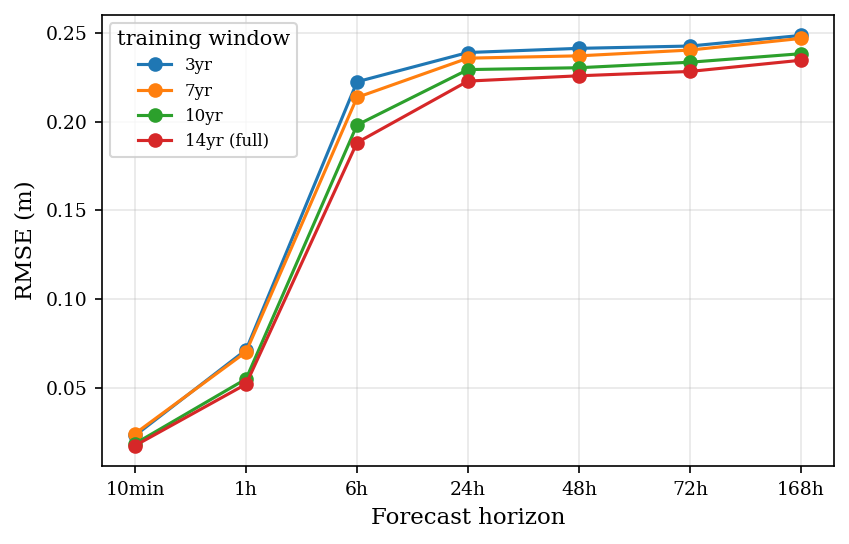

saved /content/drive/MyDrive/tidal_analysis_and_prediction/report_images/stage2_rmse_vs_training_years.pdf


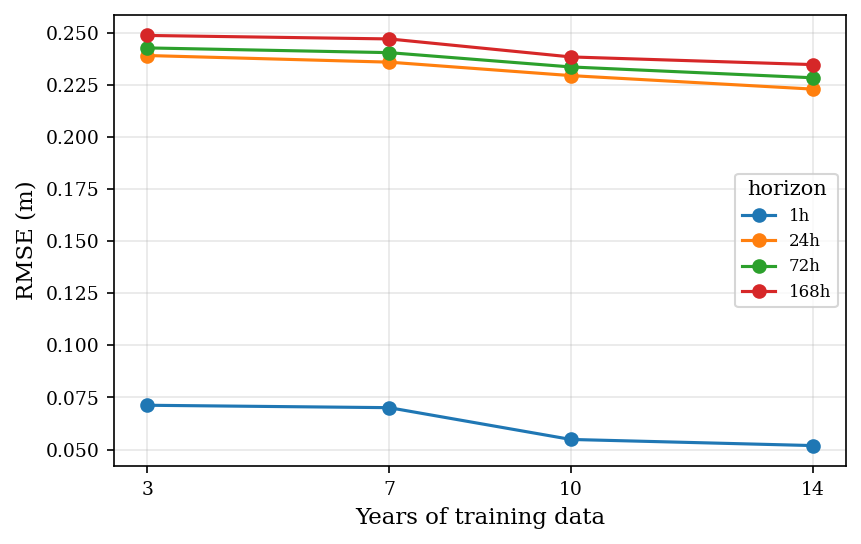

In [37]:
print("UTide-standalone RMSE per training window (isolates constituent-fit quality from the neural net):")
print(utide_only_pivot.round(4))

fig = plt.figure(figsize=(8, 5))
for name in reduced_pivot.index:
    plt.plot(HORIZON_NAMES, reduced_pivot.loc[name], marker='o', label=name)
plt.xlabel('Forecast horizon')
plt.ylabel('RMSE (m)')
plt.legend(title='training window', fontsize=8)
plt.grid(alpha=0.3)
save_fig(fig, 'stage2_reduced_training_rmse_vs_horizon')
plt.show()

fixed_horizons = ['1h', '24h', '72h', '168h']
fig = plt.figure(figsize=(8, 5))
for hname in fixed_horizons:
    ys = [reduced_pivot.loc[name, hname] for name in train_years_order.index]
    plt.plot(train_years_order.values, ys, marker='o', label=hname)
plt.xlabel('Years of training data')
plt.ylabel('RMSE (m)')
plt.legend(title='horizon', fontsize=8)
plt.grid(alpha=0.3)
plt.xticks(sorted(train_years_order.unique()))
save_fig(fig, 'stage2_rmse_vs_training_years')
plt.show()